In [45]:
words = open("names.txt", 'r').read().splitlines()

In [46]:
words[:11]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail']

In [47]:
len(words)

32033

In [48]:
max(len(w) for w in words)

15

In [49]:
b= {}

for w in words:
    # print(w) # print(w[1:])# print(list(zip(w, w[1:])))
    chs =['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1


In [50]:
sorted(b.items(), key =lambda kv: - kv[1] )

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [51]:
import torch

In [52]:
N = torch.zeros((27,27), dtype=torch.int32)


In [53]:
chars = sorted(list(set(''.join(words)))) #just to get the unique characters in the words list...that is just alphabets
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [54]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1
    

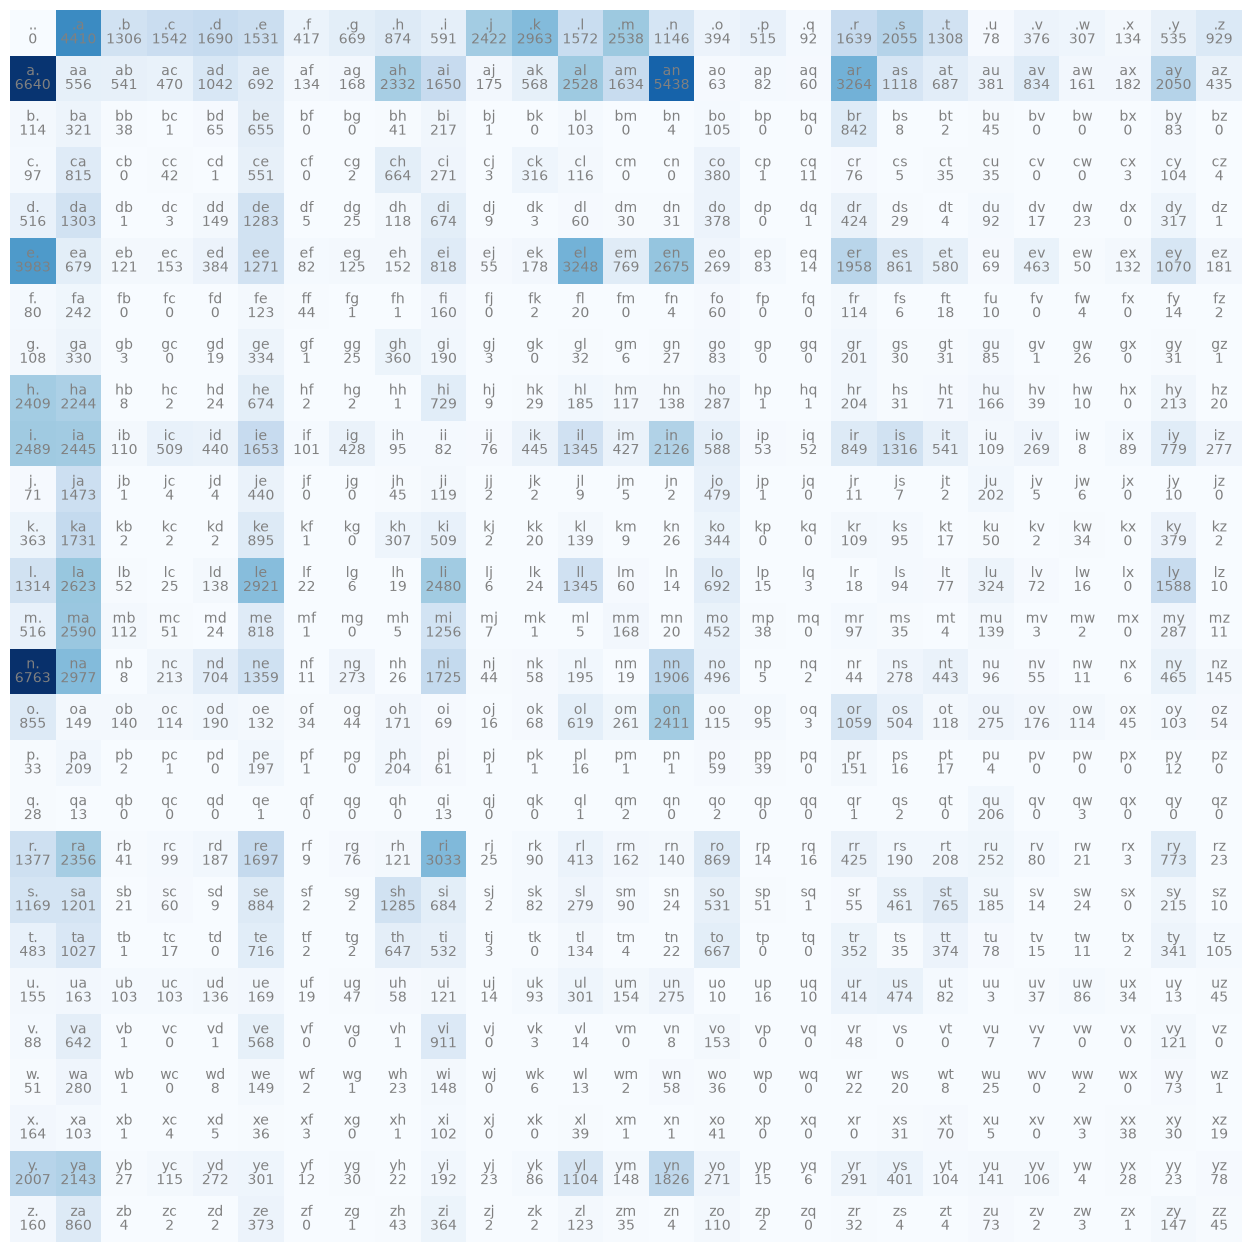

In [70]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [56]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [57]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [58]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
ix, itos[ix]

(3, 'c')

In [59]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [60]:
torch.multinomial(p, num_samples=10, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0])

In [61]:
P.sum(1, keepdim=True).shape

torch.Size([27, 1])

In [62]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [63]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [64]:

# log(a*b*c) = log(a) + log(b) + log(c)

In [72]:
log_likelihood = 0.0
n = 0
#for w in words:
for w in ["uday"]: 
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    n += 1
    log_likelihood += logprob
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n=}')


log_likelihood=tensor(-14.9794)
nll=tensor(14.9794)
nll/n=tensor(2.9959)


In [73]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [74]:
xs

tensor([ 0,  5, 13, 13,  1])

In [75]:
ys

tensor([ 5, 13, 13,  1,  0])

In [76]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [77]:

xenc.shape

torch.Size([5, 27])

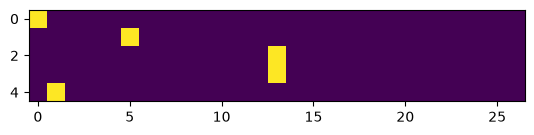

In [78]:
plt.imshow(xenc)

In [79]:
xenc.dtype

torch.float32

In [81]:
W = torch.randn((27, 27))
xenc @ W

tensor([[-1.7381, -0.3875,  1.6976, -0.0289, -0.4661,  0.1908, -1.0705, -0.2009,
         -1.7277, -0.0115, -0.8382,  0.7906,  0.1222,  0.6452, -0.4634,  1.2576,
          0.4751, -0.8370,  0.0813, -1.3701,  0.7835, -1.5442, -0.2769,  0.4890,
         -0.3828, -0.6030,  0.3641],
        [-0.8589, -1.1153, -0.3065,  1.8358,  0.3186, -0.1809, -0.7953,  0.5298,
          0.5404,  1.1204,  0.6824,  1.6652, -0.8055, -1.5529, -0.3743, -1.1740,
         -2.3141,  2.0530,  0.6082, -0.3922, -0.7444,  1.3503, -0.6271, -0.8594,
         -0.3201,  1.7940,  1.1452],
        [-0.5547, -0.1116,  0.9844,  0.2277,  0.6033,  0.1683, -0.0271, -1.1337,
         -1.0673, -0.2958,  0.0516,  1.3577, -0.4583, -0.0577,  0.5252,  0.7342,
         -0.0753,  0.8418,  1.1053, -1.2994, -0.1895,  1.5770,  0.8474,  0.1262,
         -2.8520,  0.3510,  0.3253],
        [-0.5547, -0.1116,  0.9844,  0.2277,  0.6033,  0.1683, -0.0271, -1.1337,
         -1.0673, -0.2958,  0.0516,  1.3577, -0.4583, -0.0577,  0.5252,  0.7342

In [82]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0055, 0.0211, 0.1701, 0.0303, 0.0195, 0.0377, 0.0107, 0.0255, 0.0055,
         0.0308, 0.0135, 0.0687, 0.0352, 0.0594, 0.0196, 0.1095, 0.0501, 0.0135,
         0.0338, 0.0079, 0.0682, 0.0066, 0.0236, 0.0508, 0.0212, 0.0170, 0.0448],
        [0.0082, 0.0064, 0.0143, 0.1220, 0.0268, 0.0162, 0.0088, 0.0330, 0.0334,
         0.0597, 0.0385, 0.1029, 0.0087, 0.0041, 0.0134, 0.0060, 0.0019, 0.1516,
         0.0357, 0.0131, 0.0092, 0.0751, 0.0104, 0.0082, 0.0141, 0.1170, 0.0612],
        [0.0145, 0.0226, 0.0675, 0.0317, 0.0461, 0.0299, 0.0246, 0.0081, 0.0087,
         0.0188, 0.0266, 0.0981, 0.0160, 0.0238, 0.0427, 0.0526, 0.0234, 0.0586,
         0.0762, 0.0069, 0.0209, 0.1222, 0.0589, 0.0286, 0.0015, 0.0358, 0.0349],
        [0.0145, 0.0226, 0.0675, 0.0317, 0.0461, 0.0299, 0.0246, 0.0081, 0.0087,
         0.0188, 0.0266, 0.0981, 0.0160, 0.0238, 0.0427, 0.0526, 0.0234, 0.0586,
         0.0762, 0.0069, 0.0209, 0.1222, 0.0589, 0.0286, 0.0015, 0.0358, 0.0349],
        [0.0115, 0.0131,

In [84]:
probs[0]

tensor([0.0055, 0.0211, 0.1701, 0.0303, 0.0195, 0.0377, 0.0107, 0.0255, 0.0055,
        0.0308, 0.0135, 0.0687, 0.0352, 0.0594, 0.0196, 0.1095, 0.0501, 0.0135,
        0.0338, 0.0079, 0.0682, 0.0066, 0.0236, 0.0508, 0.0212, 0.0170, 0.0448])

In [85]:
probs[0].shape

torch.Size([27])

In [86]:

probs[0].sum()

tensor(1.)

In [87]:
# (5, 27) @ (27, 27) -> (5, 27)

In [89]:

# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [ ]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character i.e sftmax